In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cmcrameri import cm as cmc
import cmocean as cmo
import json
from shapely.geometry import shape, Point
from matplotlib.gridspec import GridSpec

SET INPUT OUTPUT FILES AND DIRS FOR PLOTTING

In [2]:
input_file = '../AA_winner_model_LSTM_52_46_bs16_lr2e-4_pat6x5_do0.2/mc_test_results.nc'
output_dir = '../AA_winner_model_LSTM_52_46_bs16_lr2e-4_pat6x5_do0.2/plots'
if not os.path.exists(input_file):
    raise FileNotFoundError(f"Input file not found: {input_file}")

In [3]:
results = xr.open_dataset(input_file)
os.makedirs(output_dir, exist_ok=True)

# Build real data mask (exclude augmented data points) for consistency with pre-computed RMSE
real_data_mask = None
if 'TEMP_augs' in results and 'PSAL_augs' in results:
    real_data_mask = (results['TEMP_augs'].values == 0) & (results['PSAL_augs'].values == 0)
    n_real = np.sum(real_data_mask)
    n_total = real_data_mask.size
    print(f"Real data mask: {n_real}/{n_total} depth points ({100*n_real/n_total:.1f}%)")

results

Real data mask: 892725/2672761 depth points (33.4%)


<xarray.Dataset> Size: 389MB
Dimensions:                (profile: 29371, depth: 91)
Coordinates:
  * profile                (profile) int64 235kB 0 1 2 3 ... 29368 29369 29370
  * depth                  (depth) float64 728B 0.0 5.0 10.0 ... 4.3e+03 4.4e+03
Data variables: (12/41)
    T_glorys               (profile, depth) float64 21MB ...
    S_glorys               (profile, depth) float64 21MB ...
    T_obs_anomaly          (profile, depth) float64 21MB ...
    S_obs_anomaly          (profile, depth) float64 21MB ...
    T_pred_anomaly         (profile, depth) float64 21MB ...
    S_pred_anomaly         (profile, depth) float64 21MB ...
    ...                     ...
    PSAL_aug_fraction      (profile) float32 117kB ...
    TEMP_augs              (profile, depth) float64 21MB 1.0 0.0 ... -1.0 -1.0
    PSAL_augs              (profile, depth) float64 21MB 1.0 0.0 ... -1.0 -1.0
    max_depth_idx          (profile) int64 235kB ...
    profile_lengths        (profile) int64 235kB ...
    ice_conc               (profile) float32 117kB ...
Attributes: (12/14)
    title:                       LSTM Model Test Results with Monte Carlo Dro...
    description:                 Comprehensive results including climatology,...
    model_architecture:          LSTM 52-46
    test_data_file:              /data/FRESH-CARE/data_for_LSTM/data/var_dept...
    MC_dropout_samples:          500
    output_variables:            ['temperature', 'salinity']
    ...                          ...
    n_depth_levels:              91
    glorys_rmse_real_data_only:  1
    T_rmse_total:                0.5128852467411663
    S_rmse_total:                0.2288903117319829
    training_time_seconds:       31104.72671031952
    mc_prediction_time_seconds:  1264.4261329174042

In [4]:
# --- Load arctic regions from GeoJSON ---
regions_path = '/home/nicolas/SACO/FRESH-CARE/Arctic_masks/geojson_masks/arctic_regions.json'
with open(regions_path) as f:
    regions_geojson = json.load(f)

COMBINED T & S RMSE BY DEPTH — ALL ARCTIC REGIONS (7×4 panel)

In [5]:
# --- Build region polygons and metadata ---
region_ids = []
region_names = {}
region_polygons = {}
for feature in regions_geojson['features']:
    rid = feature['properties']['id']
    rname = feature['properties']['name_en']
    region_ids.append(rid)
    region_names[rid] = rname
    region_polygons[rid] = shape(feature['geometry'])

# --- Assign each profile to a region ---
lats = results['LATITUDE'].values
lons = results['LONGITUDE'].values
n_profiles = len(lats)

profile_region = np.full(n_profiles, 'Unassigned', dtype=object)
for i in range(n_profiles):
    pt = Point(lons[i], lats[i])
    for rid, poly in region_polygons.items():
        if poly.contains(pt):
            profile_region[i] = rid
            break


In [6]:

# --- Compute regional RMSE by depth ---
depths = results['depth'].values
T_error = results['T_error'].values
T_glorys_error = results['T_glorys_error'].values
S_error = results['S_error'].values
S_glorys_error = results['S_glorys_error'].values

active_regions = [rid for rid in region_ids if np.any(profile_region == rid)]

regional_Trmse = {}
regional_Trmse_glorys = {}
regional_Tcounts = {}
regional_Srmse = {}
regional_Srmse_glorys = {}

for rid in active_regions:
    mask = profile_region == rid
    t_err   = T_error[mask, :]
    t_err_g = T_glorys_error[mask, :]
    s_err   = S_error[mask, :]
    s_err_g = S_glorys_error[mask, :]
    if real_data_mask is not None:
        rdm = real_data_mask[mask, :]
        t_err   = np.where(rdm, t_err,   np.nan)
        t_err_g = np.where(rdm, t_err_g, np.nan)
        s_err   = np.where(rdm, s_err,   np.nan)
        s_err_g = np.where(rdm, s_err_g, np.nan)
    regional_Trmse[rid]         = np.sqrt(np.nanmean(t_err   ** 2, axis=0))
    regional_Trmse_glorys[rid]  = np.sqrt(np.nanmean(t_err_g ** 2, axis=0))
    regional_Srmse[rid]         = np.sqrt(np.nanmean(s_err   ** 2, axis=0))
    regional_Srmse_glorys[rid]  = np.sqrt(np.nanmean(s_err_g ** 2, axis=0))
    regional_Tcounts[rid]       = int(mask.sum())

# --- Pre-compute real obs count per depth per region (for half-violin) ---
S_obs_insitu = results['S_obs_insitu'].values      # (n_profiles, n_depths)
psal_augs_all = results['PSAL_augs'].values        # 0 = real, nonzero = augmented
real_s_obs_mask = psal_augs_all == 0

regional_Snobs = {}
for rid in active_regions:
    mask = profile_region == rid
    s_obs_r = S_obs_insitu[mask, :]
    real_r  = real_s_obs_mask[mask, :]
    regional_Snobs[rid] = np.sum(np.isfinite(s_obs_r) & real_r, axis=0)

# --- Compute coverage depth threshold per region ---
# Find the last depth where > COVERAGE_THRESHOLD fraction of profiles have valid data.
# COVERAGE_THRESHOLD = 0   → last depth with any valid data (old behaviour)
# COVERAGE_THRESHOLD = 0.05 → last depth where >= 5% of profiles have valid data
COVERAGE_THRESHOLD = 0.0

regional_T_depth5pct = {}
regional_S_depth5pct = {}

for rid in active_regions:
    mask = profile_region == rid
    n_reg = int(mask.sum())

    # T: valid = finite after applying real_data_mask
    t_err = T_error[mask, :]
    if real_data_mask is not None:
        rdm = real_data_mask[mask, :]
        t_err = np.where(rdm, t_err, np.nan)
    t_valid_frac = np.sum(np.isfinite(t_err), axis=0) / n_reg
    valid_idx_T = np.where(t_valid_frac > COVERAGE_THRESHOLD)[0]
    regional_T_depth5pct[rid] = depths[valid_idx_T[-1]] if len(valid_idx_T) > 0 else depths[0]

    # S: use already-computed Snobs (real obs count per depth)
    s_valid_frac = regional_Snobs[rid] / n_reg
    valid_idx_S = np.where(s_valid_frac > COVERAGE_THRESHOLD)[0]
    regional_S_depth5pct[rid] = depths[valid_idx_S[-1]] if len(valid_idx_S) > 0 else depths[0]


/tmp/ipykernel_305081/2223768371.py:28: RuntimeWarning: Mean of empty slice
  regional_Trmse[rid]         = np.sqrt(np.nanmean(t_err   ** 2, axis=0))
/tmp/ipykernel_305081/2223768371.py:29: RuntimeWarning: Mean of empty slice
  regional_Trmse_glorys[rid]  = np.sqrt(np.nanmean(t_err_g ** 2, axis=0))
/tmp/ipykernel_305081/2223768371.py:30: RuntimeWarning: Mean of empty slice
  regional_Srmse[rid]         = np.sqrt(np.nanmean(s_err   ** 2, axis=0))
/tmp/ipykernel_305081/2223768371.py:31: RuntimeWarning: Mean of empty slice
  regional_Srmse_glorys[rid]  = np.sqrt(np.nanmean(s_err_g ** 2, axis=0))


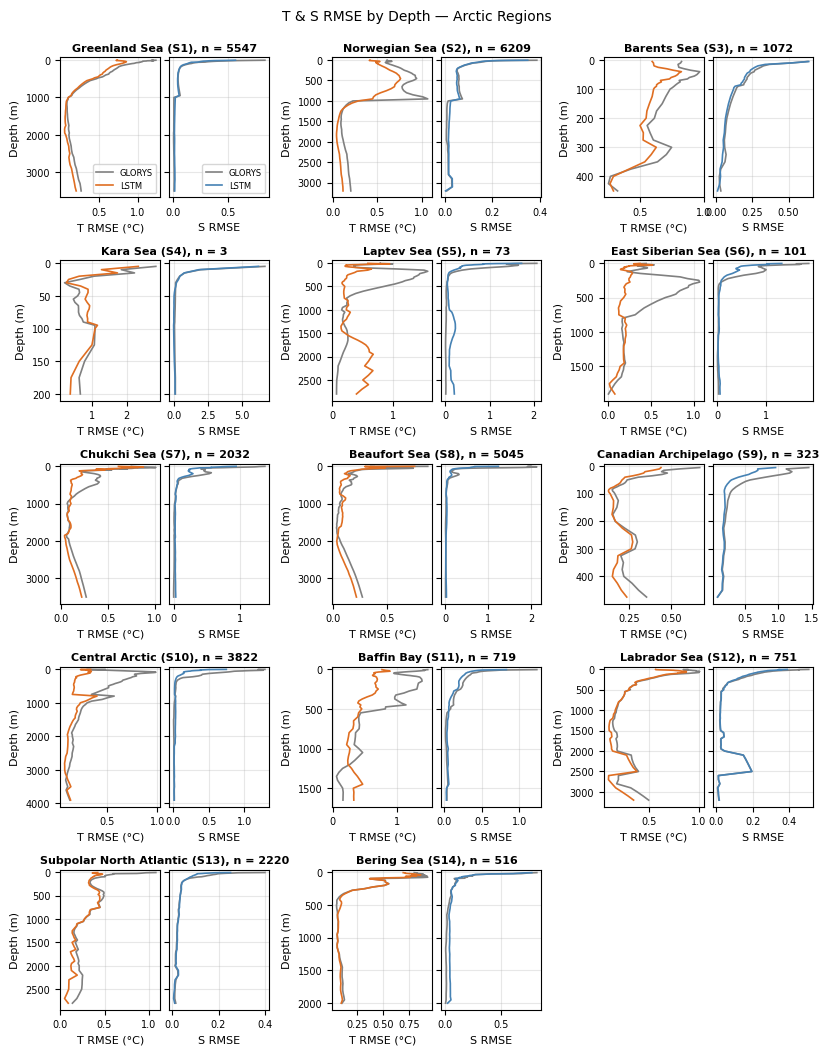

Saved to: ../AA_winner_model_LSTM_52_46_bs16_lr2e-4_pat6x5_do0.2/plots/TS_rmse_by_depth_regions_combined.png


In [41]:

# --- Plot ---
# 5 rows x 3 region-pairs: each row has three regions, each region = T | S
# GridSpec uses 8 columns: [T|S|gap|T|S|gap|T|S]
# This lets us control intra-pair and inter-pair spacing independently.

# --- Per-region depth threshold overrides ---
# Regions listed here use the given coverage threshold instead of the global COVERAGE_THRESHOLD.
# The threshold is the minimum fraction of profiles that must have valid data at a depth
# for that depth to be shown. Same semantics as COVERAGE_THRESHOLD in the computation cell.
# COVERAGE_THRESHOLD = 0    → last depth with any valid data
# COVERAGE_THRESHOLD = 0.05 → last depth where > 5% of profiles have valid data
DEPTH_OVERRIDES = {
    # 'S1': 0.10,
    # 'S3': 0.05,
}

def _depth_from_threshold(rid, thr):
    """Recompute max-depth limits for a region using a specific threshold."""
    mask = profile_region == rid
    n_reg = int(mask.sum())
    t_err = T_error[mask, :]
    if real_data_mask is not None:
        rdm = real_data_mask[mask, :]
        t_err = np.where(rdm, t_err, np.nan)
    t_frac = np.sum(np.isfinite(t_err), axis=0) / n_reg
    idx_T = np.where(t_frac > thr)[0]
    d_T = depths[idx_T[-1]] if len(idx_T) > 0 else depths[0]
    s_frac = regional_Snobs[rid] / n_reg
    idx_S = np.where(s_frac > thr)[0]
    d_S = depths[idx_S[-1]] if len(idx_S) > 0 else depths[0]
    return d_T, d_S

COLOR_T_LSTM = "#DF6E22"   # mild orange
COLOR_S_LSTM = 'steelblue'
COLOR_GLORYS = 'gray'

n_regions = len(active_regions)
n_rows = 5

fig = plt.figure(figsize=(8.1, n_rows * 2.14))

gs = GridSpec(n_rows, 8, figure=fig,
              width_ratios=[1, 1, 0.45, 1, 1, 0.45, 1, 1],
              left=0.06, right=0.99, top=0.92, bottom=0.03,
              wspace=0.10, hspace=0.45)

# GridSpec column mapping: col_offset -> (T_col, S_col)
gs_cols = {0: (0, 1), 1: (3, 4), 2: (6, 7)}

pair_info = []

for row in range(n_rows):
    for col_offset, region_idx in enumerate([row * 3, row * 3 + 1, row * 3 + 2]):
        tc, sc = gs_cols[col_offset]
        ax_T = fig.add_subplot(gs[row, tc])
        ax_S = fig.add_subplot(gs[row, sc])

        if region_idx >= n_regions:
            ax_T.axis('off')
            ax_S.axis('off')
            continue

        rid   = active_regions[region_idx]
        rname = region_names[rid]
        count = regional_Tcounts[rid]

        T_rmse   = regional_Trmse[rid]
        T_rmse_g = regional_Trmse_glorys[rid]
        S_rmse   = regional_Srmse[rid]
        S_rmse_g = regional_Srmse_glorys[rid]

        if rid in DEPTH_OVERRIDES:
            max_depth_T, max_depth_S = _depth_from_threshold(rid, DEPTH_OVERRIDES[rid])
        else:
            max_depth_T = regional_T_depth5pct[rid]
            max_depth_S = regional_S_depth5pct[rid]

        # --- T panel ---
        ax_T.plot(T_rmse_g, depths, color=COLOR_GLORYS,  linewidth=1.2, label='GLORYS')
        ax_T.plot(T_rmse,   depths, color=COLOR_T_LSTM, linewidth=1.2, label='LSTM')
        ax_T.set_ylim(max_depth_T * 1.05, -max_depth_T * 0.02)
        ax_T.set_xlabel('T RMSE (°C)', fontsize=8)
        ax_T.set_ylabel('Depth (m)', fontsize=8)
        ax_T.grid(True, alpha=0.3)
        ax_T.tick_params(labelsize=7)
        if row == 0 and col_offset == 0:
            ax_T.legend(fontsize=6, loc='lower right')

        # --- S panel: no ylabel, no y-tick labels (depth already shown on T) ---
        ax_S.plot(S_rmse_g, depths, color=COLOR_GLORYS,  linewidth=1.2, label='GLORYS')
        ax_S.plot(S_rmse,   depths, color=COLOR_S_LSTM, linewidth=1.2, label='LSTM')
        ax_S.set_ylim(max_depth_S * 1.05, -max_depth_S * 0.02)
        ax_S.set_xlabel('S RMSE', fontsize=8)
        ax_S.tick_params(labelleft=False, labelsize=7)
        ax_S.grid(True, alpha=0.3)
        if row == 0 and col_offset == 0:
            ax_S.legend(fontsize=6, loc='lower right')

        pair_info.append((ax_T, ax_S, f"{rname} ({rid}), n = {count}"))

fig.suptitle('T & S RMSE by Depth — Arctic Regions', fontsize=10, y=0.965)

# Shared titles centered over each T–S pair
for ax_T, ax_S, title in pair_info:
    pos_T = ax_T.get_position()
    pos_S = ax_S.get_position()
    x_mid = (pos_T.x0 + pos_S.x1) / 2
    y_top = max(pos_T.y1, pos_S.y1)
    fig.text(x_mid, y_top + 0.004, title,
             ha='center', va='bottom', fontsize=8, fontweight='bold')

path = os.path.join(output_dir, 'TS_rmse_by_depth_regions_combined.png')
fig.savefig(path, dpi=350, bbox_inches='tight')
plt.show()
print(f'Saved to: {path}')


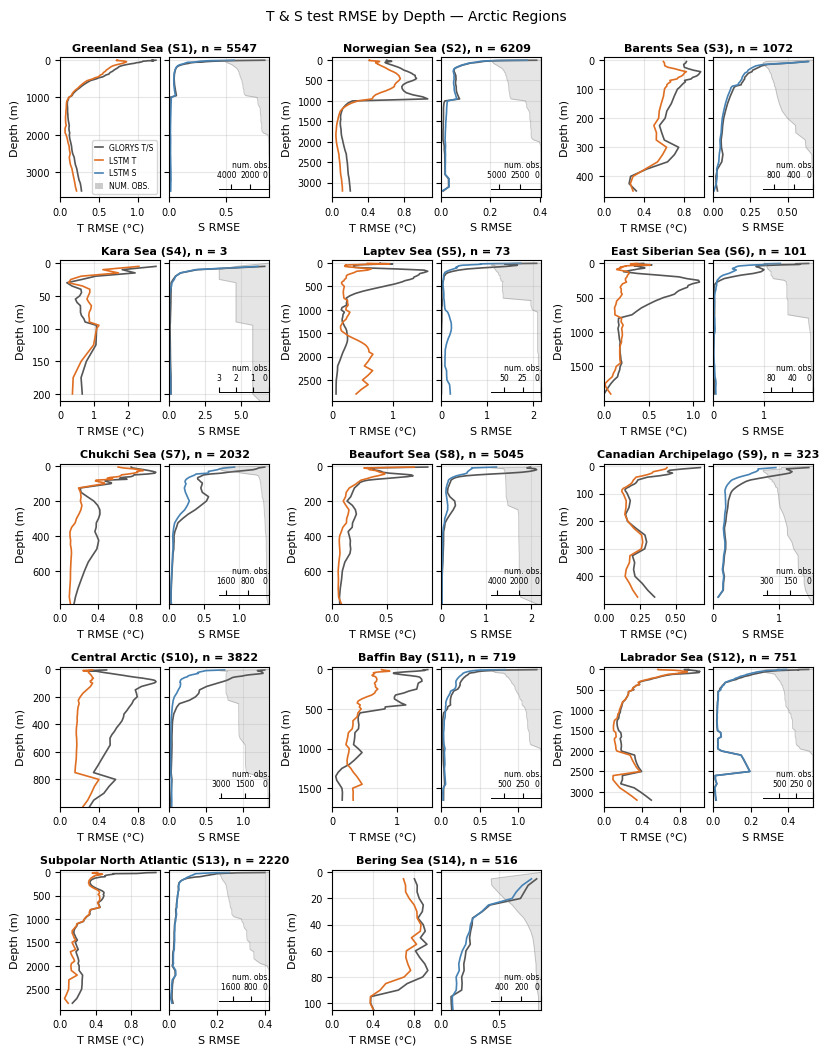

Saved to: ../AA_winner_model_LSTM_52_46_bs16_lr2e-4_pat6x5_do0.2/plots/TS_rmse_by_depth_regions_combined_wnobs.png


In [51]:

# --- Plot ---
# 5 rows x 3 region-pairs: each row has three regions, each region = T | S + nobs violin
# GridSpec uses 8 columns: [T|S|gap|T|S|gap|T|S]

import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.lines as mlines

# --- Per-region depth threshold overrides ---
# Regions listed here use the given coverage threshold instead of the global COVERAGE_THRESHOLD.
# The threshold is the minimum fraction of profiles that must have valid data at a depth
# for that depth to be shown. Same semantics as COVERAGE_THRESHOLD in the computation cell.
# COVERAGE_THRESHOLD = 0    → last depth with any valid data
# COVERAGE_THRESHOLD = 0.05 → last depth where > 5% of profiles have valid data
DEPTH_OVERRIDES = {
    # 'S1': 0.10,
    # 'S3': 0.05,
    'S7':0.05,
    'S8':0.05,
    'S10':0.02,
    'S14':0.055
}

def _depth_from_threshold(rid, thr):
    """Recompute max-depth limits for a region using a specific threshold."""
    mask = profile_region == rid
    n_reg = int(mask.sum())
    t_err = T_error[mask, :]
    if real_data_mask is not None:
        rdm = real_data_mask[mask, :]
        t_err = np.where(rdm, t_err, np.nan)
    t_frac = np.sum(np.isfinite(t_err), axis=0) / n_reg
    idx_T = np.where(t_frac > thr)[0]
    d_T = depths[idx_T[-1]] if len(idx_T) > 0 else depths[0]
    s_frac = regional_Snobs[rid] / n_reg
    idx_S = np.where(s_frac > thr)[0]
    d_S = depths[idx_S[-1]] if len(idx_S) > 0 else depths[0]
    return d_T, d_S

COLOR_T_LSTM = "#DF6E22"   # mild orange
COLOR_S_LSTM = 'steelblue'
COLOR_GLORYS = "#565656"
COLOR_NOBS   = 'gray'
COLOR_NOBS_AX = 'black'   # color for the secondary nobs axis
VIOLIN_FRAC  = 0.5        # fraction of S x-range occupied by the violin

# --- Manual x-tick overrides to avoid label overlap between adjacent panels ---
# Key: (row, col, panel) where row=0..4, col=0..2, panel='T' or 'S'
# Value: list of tick positions to use for that axis
XTICK_OVERRIDES = {
    # (row, col, 'T'): [0.0, 0.5, 1.0],
    # (row, col, 'S'): [0.0, 0.1, 0.2],
    (3, 0, 'T'): [0.0, 0.4, 0.8],
    (0, 1, 'T'): [0.0, 0.4, 0.8],
    (0, 2, 'T'): [0.0, 0.4, 0.8],
    (2, 0, 'T'): [0.0, 0.4, 0.8],
    (3, 2, 'T'): [0.0, 0.4, 0.8],
    (4, 0, 'T'): [0.0, 0.4, 0.8],
    (4, 1, 'T'): [0.0, 0.4, 0.8]
}

# --- Manual tick overrides for the secondary nobs axis ---
# Key: region id (string, e.g. 'S1')
# Value can be either:
#   1) list of numeric tick locations, e.g. [0, 50, 100]
#   2) list of (location, label) pairs, e.g. [(0, '0   '), (50, '50 '), (100, '100') ]
NOBS_TICK_OVERRIDES = {
    # 'S1': [0, 50, 100],
    # 'S3': [0, 200, 400],
    'S2': [(0, '0   '), (2500, '2500'), (5000, '5000  ')],
    'S1': [(0, '0   '), (2000, '2000'), (4000, '4000   ')],
    'S13': [(0, '0   '), (800, '800'), (1600, '1600  ')],
}

n_regions = len(active_regions)
n_rows = 5

fig = plt.figure(figsize=(8.1, n_rows * 2.14))

gs = GridSpec(n_rows, 8, figure=fig,
              width_ratios=[1, 1, 0.45, 1, 1, 0.45, 1, 1],
              left=0.06, right=0.99, top=0.92, bottom=0.03,
              wspace=0.10, hspace=0.45)

# GridSpec column mapping: col_offset -> (T_col, S_col)
gs_cols = {0: (0, 1), 1: (3, 4), 2: (6, 7)}

pair_info = []

for row in range(n_rows):
    for col_offset, region_idx in enumerate([row * 3, row * 3 + 1, row * 3 + 2]):
        tc, sc = gs_cols[col_offset]
        ax_T = fig.add_subplot(gs[row, tc])
        ax_S = fig.add_subplot(gs[row, sc])

        if region_idx >= n_regions:
            ax_T.axis('off')
            ax_S.axis('off')
            continue

        rid   = active_regions[region_idx]
        rname = region_names[rid]
        count = regional_Tcounts[rid]

        T_rmse   = regional_Trmse[rid]
        T_rmse_g = regional_Trmse_glorys[rid]
        S_rmse   = regional_Srmse[rid]
        S_rmse_g = regional_Srmse_glorys[rid]
        n_obs    = regional_Snobs[rid]

        if rid in DEPTH_OVERRIDES:
            max_depth_T, max_depth_S = _depth_from_threshold(rid, DEPTH_OVERRIDES[rid])
        else:
            max_depth_T = regional_T_depth5pct[rid]
            max_depth_S = regional_S_depth5pct[rid]

        # --- T panel ---
        ax_T.plot(T_rmse_g, depths, color=COLOR_GLORYS,  linewidth=1.2, label='GLORYS')
        ax_T.plot(T_rmse,   depths, color=COLOR_T_LSTM, linewidth=1.2, label='LSTM')
        ax_T.set_ylim(max_depth_T * 1.05, -max_depth_T * 0.02)
        ax_T.set_xlim(left=0)
        ax_T.set_xlabel('T RMSE (°C)', fontsize=8)
        ax_T.set_ylabel('Depth (m)', fontsize=8)
        ax_T.grid(True, alpha=0.3)
        ax_T.tick_params(labelsize=7)
        if (row, col_offset, 'T') in XTICK_OVERRIDES:
            ax_T.set_xticks(XTICK_OVERRIDES[(row, col_offset, 'T')])
        if row == 0 and col_offset == 0:
            glorys_handle = mlines.Line2D([], [], color=COLOR_GLORYS, linewidth=1.2, label='GLORYS T/S')
            lstm_t_handle = mlines.Line2D([], [], color=COLOR_T_LSTM, linewidth=1.2, label='LSTM T')
            lstm_s_handle = mlines.Line2D([], [], color=COLOR_S_LSTM, linewidth=1.2, label='LSTM S')
            obs_patch = mpatches.Patch(facecolor=COLOR_NOBS, alpha=0.4, label='NUM. OBS.')
            ax_T.legend(handles=[glorys_handle, lstm_t_handle, lstm_s_handle, obs_patch],
                        fontsize=5.5, handlelength=1.0, loc='lower right')

        # --- S panel: no ylabel, no y-tick labels (depth already shown on T) ---
        ax_S.plot(S_rmse_g, depths, color=COLOR_GLORYS,  linewidth=1.2, label='GLORYS')
        ax_S.plot(S_rmse,   depths, color=COLOR_S_LSTM, linewidth=1.2, label='LSTM')
        ax_S.set_ylim(max_depth_S * 1.05, -max_depth_S * 0.02)
        ax_S.set_xlim(left=0)
        ax_S.set_xlabel('S RMSE', fontsize=8)
        ax_S.tick_params(labelleft=False, labelsize=7)
        ax_S.grid(True, alpha=0.3)
        if (row, col_offset, 'S') in XTICK_OVERRIDES:
            ax_S.set_xticks(XTICK_OVERRIDES[(row, col_offset, 'S')])


        # --- Half-violin: normalized obs distribution, overlaid on S panel ---
        x_min, x_max = ax_S.get_xlim()
        x_range = x_max - x_min
        nobs_norm = n_obs / n_obs.max() if n_obs.max() > 0 else n_obs
        violin_x = x_max - nobs_norm * (VIOLIN_FRAC * x_range)
        ax_S.fill_betweenx(depths, x_max, violin_x,
                           color=COLOR_NOBS, alpha=0.20, linewidth=0)
        ax_S.plot(violin_x, depths, color=COLOR_NOBS, alpha=0.45, linewidth=0.7)
        # Restore xlim so the violin doesn't expand the axis
        ax_S.set_xlim(x_min, x_max)

        # --- Secondary x-axis showing absolute nobs count (aligned with violin) ---
        # Spans VIOLIN_FRAC of the axes width, anchored to the right edge.
        # Axis runs right-to-left: right edge = 0, left edge = nobs_max.
        # Spine and ticks are drawn above the main x-axis line; ticks point upward.
        nobs_max_val = int(n_obs.max())
        if nobs_max_val > 0:
            nobs_ax = ax_S.inset_axes(
                [1.0 - VIOLIN_FRAC, 0.05, VIOLIN_FRAC, 0.01]
            )
            nobs_ax.set_xlim(nobs_max_val, 0)  # left = max nobs, right = 0
            nobs_ax.set_facecolor('none')
            nobs_ax.set_yticks([])
            for sp in ('bottom', 'left', 'right'):
                nobs_ax.spines[sp].set_visible(False)
            nobs_ax.spines['top'].set_linewidth(0.7)
            nobs_ax.spines['top'].set_color(COLOR_NOBS_AX)
            nobs_ax.xaxis.set_ticks_position('top')
            nobs_ax.tick_params(axis='x', direction='out', top=True,
                                labelsize=5.5, colors=COLOR_NOBS_AX)
            if rid in NOBS_TICK_OVERRIDES:
                override = NOBS_TICK_OVERRIDES[rid]
                if len(override) > 0 and isinstance(override[0], (tuple, list)) and len(override[0]) == 2:
                    # Option 2: explicit (location, label) pairs
                    tick_locs = [float(t[0]) for t in override]
                    labels = [str(t[1]) for t in override]
                else:
                    # Option 1: numeric tick locations only
                    tick_locs = override
                    labels = ['0   ' if t == 0 else str(int(t)) for t in tick_locs]
            else:
                # Use MaxNLocator to compute nice tick positions, then freeze them
                locator = mticker.MaxNLocator(nbins=3, integer=True)
                locator.set_axis(nobs_ax.xaxis)
                tick_locs = locator.tick_values(0, nobs_max_val).tolist()
                # Keep only ticks within [0, nobs_max_val]
                tick_locs = [t for t in tick_locs if 0 <= t <= nobs_max_val]
                labels = ['0   ' if t == 0 else str(int(t)) for t in tick_locs]
            # Apply as a FixedLocator to avoid set_xticklabels warnings
            nobs_ax.xaxis.set_major_locator(mticker.FixedLocator(tick_locs))
            nobs_ax.set_xticklabels(labels)
            # 'n obs:' label above the nobs axis, right-aligned to the S panel edge
            ax_S.text(1.0, 0.2, 'num. obs.', transform=ax_S.transAxes,
                      ha='right', va='bottom', fontsize=5.5, color=COLOR_NOBS_AX)

        pair_info.append((ax_T, ax_S, f"{rname} ({rid}), n = {count}"))

fig.suptitle('T & S test RMSE by Depth — Arctic Regions', fontsize=10, y=0.965)

# Shared titles centered over each T–S pair
for ax_T, ax_S, title in pair_info:
    pos_T = ax_T.get_position()
    pos_S = ax_S.get_position()
    x_mid = (pos_T.x0 + pos_S.x1) / 2
    y_top = max(pos_T.y1, pos_S.y1)
    fig.text(x_mid, y_top + 0.004, title,
             ha='center', va='bottom', fontsize=8, fontweight='bold')

path = os.path.join(output_dir, 'TS_rmse_by_depth_regions_combined_wnobs.png')
fig.savefig(path, dpi=350, bbox_inches='tight')
plt.show()
print(f'Saved to: {path}')


In [22]:
# --- Quick check: unassigned profiles ---
n_unassigned = int(np.sum(profile_region == 'Unassigned'))
n_total = len(profile_region)
n_assigned = n_total - n_unassigned
print(f"Total profiles: {n_total}")
print(f"Assigned to a region: {n_assigned}")
print(f"Unassigned: {n_unassigned} ({100*n_unassigned/n_total:.1f}%)")

if n_unassigned > 0:
    mask_u = profile_region == 'Unassigned'
    T_err_u = results['T_error'].values[mask_u, :]
    T_err_g_u = results['T_glorys_error'].values[mask_u, :]
    S_err_u = results['S_error'].values[mask_u, :]
    S_err_g_u = results['S_glorys_error'].values[mask_u, :]

    # Apply real data mask to exclude augmented data points
    if real_data_mask is not None:
        u_rdm = real_data_mask[mask_u, :]
        T_err_u = np.where(u_rdm, T_err_u, np.nan)
        T_err_g_u = np.where(u_rdm, T_err_g_u, np.nan)
        S_err_u = np.where(u_rdm, S_err_u, np.nan)
        S_err_g_u = np.where(u_rdm, S_err_g_u, np.nan)

    T_rmse_u = np.sqrt(np.nanmean(T_err_u**2, axis=0))
    T_rmse_g_u = np.sqrt(np.nanmean(T_err_g_u**2, axis=0))

    S_rmse_u = np.sqrt(np.nanmean(S_err_u**2, axis=0))

    S_rmse_g_u = np.sqrt(np.nanmean(S_err_g_u**2, axis=0))    
    
    print(f"Unassigned — mean S RMSE (GLORYS): {np.nanmean(S_rmse_g_u):.4f}")

    print(f"Unassigned — mean S RMSE (LSTM): {np.nanmean(S_rmse_u):.4f}")

    print(f"\nUnassigned — mean T RMSE (LSTM): {np.nanmean(T_rmse_u):.4f}")    
    
    print(f"Unassigned — mean T RMSE (GLORYS): {np.nanmean(T_rmse_g_u):.4f}")

Total profiles: 29371
Assigned to a region: 28433
Unassigned: 938 (3.2%)
Unassigned — mean S RMSE (GLORYS): 0.1524
Unassigned — mean S RMSE (LSTM): 0.1201

Unassigned — mean T RMSE (LSTM): 0.6281
Unassigned — mean T RMSE (GLORYS): 0.8201


Total profiles: 29371
Assigned to a region: 28433
Unassigned: 938 (3.2%)
Unassigned — mean S RMSE (GLORYS): 0.1524
Unassigned — mean S RMSE (LSTM): 0.1201

Unassigned — mean T RMSE (LSTM): 0.6281
Unassigned — mean T RMSE (GLORYS): 0.8201


/tmp/ipykernel_317678/1136195317.py:24: RuntimeWarning: Mean of empty slice
  T_rmse_u = np.sqrt(np.nanmean(T_err_u**2, axis=0))
/tmp/ipykernel_317678/1136195317.py:25: RuntimeWarning: Mean of empty slice
  T_rmse_g_u = np.sqrt(np.nanmean(T_err_g_u**2, axis=0))
/tmp/ipykernel_317678/1136195317.py:27: RuntimeWarning: Mean of empty slice
  S_rmse_u = np.sqrt(np.nanmean(S_err_u**2, axis=0))
/tmp/ipykernel_317678/1136195317.py:29: RuntimeWarning: Mean of empty slice
  S_rmse_g_u = np.sqrt(np.nanmean(S_err_g_u**2, axis=0))


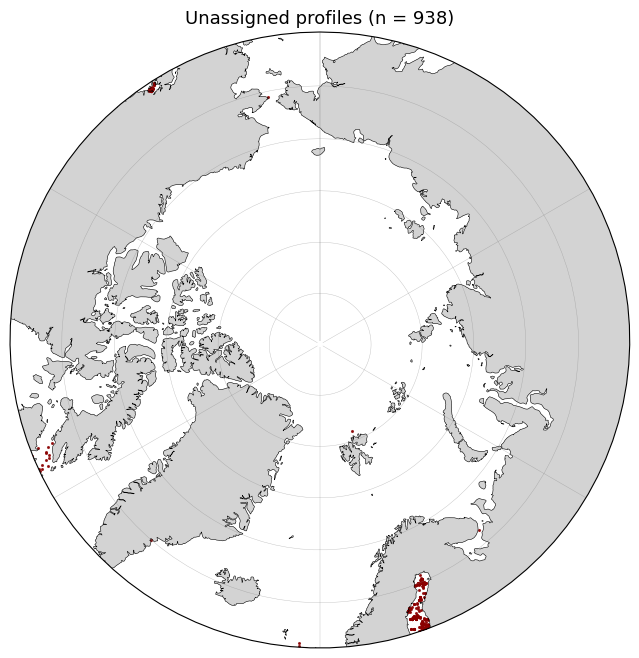

In [11]:
# Plot locations of unassigned profiles
mask_u = profile_region == 'Unassigned'
x_vals = results['LONGITUDE'].values[mask_u]
y_vals = results['LATITUDE'].values[mask_u]

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo())
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

sc = ax.scatter(
    x_vals, y_vals,
    s=1.5,
    c='darkred',
    alpha=0.8,
    transform=ccrs.PlateCarree()
)

plt.title(f"Unassigned profiles (n = {int(mask_u.sum())})", fontsize=13)
plt.show()


In [12]:

# --- LaTeX table: mean T & S metrics by Arctic region ---
# Rows (8): T RMSE LSTM, S RMSE LSTM, T RMSE GLORYS, S RMSE GLORYS,
#            T improvement, S improvement, T uncertainty, S uncertainty
# Columns: metric label + 7 regions per block (14 regions → 2 blocks in one tabularx)
# Improvement = GLORYS RMSE − LSTM RMSE (absolute, depth-averaged)
# Uncertainty from T_uncertainty / S_uncertainty variables in the dataset
# Note: uncertainties are model outputs — no real-data masking needed.

T_unc_all = results['T_uncertainty'].values   # (n_profiles, n_depths)
S_unc_all = results['S_uncertainty'].values

regional_Tunc = {}
regional_Sunc = {}
for rid in active_regions:
    mask = profile_region == rid
    regional_Tunc[rid] = np.nanmean(T_unc_all[mask, :])
    regional_Sunc[rid] = np.nanmean(S_unc_all[mask, :])

metric_labels = [
    r'T RMSE$_\text{LSTM}$ ($^\circ$C)',
    r'S RMSE$_\text{LSTM}$',
    r'T RMSE$_\text{GLORYS}$ ($^\circ$C)',
    r'S RMSE$_\text{GLORYS}$',
    r'T Improvement ($^\circ$C)',
    r'S Improvement',
    r'T Uncertainty ($^\circ$C)',
    r'S Uncertainty',
]

def get_region_metrics(rid):
    t_rmse   = np.nanmean(regional_Trmse[rid])
    s_rmse   = np.nanmean(regional_Srmse[rid])
    t_rmse_g = np.nanmean(regional_Trmse_glorys[rid])
    s_rmse_g = np.nanmean(regional_Srmse_glorys[rid])
    t_imp    = t_rmse_g - t_rmse
    s_imp    = s_rmse_g - s_rmse
    t_unc    = regional_Tunc[rid]
    s_unc    = regional_Sunc[rid]
    return [t_rmse, s_rmse, t_rmse_g, s_rmse_g, t_imp, s_imp, t_unc, s_unc]

# Row separators: draw \hline after each T/S pair (indices 1,3,5,7)
separator_after = {1, 3, 5, 7}

def make_block(region_subset):
    """Returns a list of LaTeX lines for one block (header + 8 metric rows)."""
    col_headers = [r'\textbf{' + rid + r'}' for rid in region_subset]
    header_line = r'\textbf{Metric} & ' + ' & '.join(col_headers) + r' \\'
    all_metrics = {rid: get_region_metrics(rid) for rid in region_subset}
    lines = [header_line, r'\hline']
    for i, label in enumerate(metric_labels):
        vals = [f'{all_metrics[rid][i]:.2f}' for rid in region_subset]
        lines.append(label + ' & ' + ' & '.join(vals) + r' \\')
        if i in separator_after:
            lines.append(r'\hline')
    return lines

# Split active_regions into two halves
split = len(active_regions) // 2
first_half  = active_regions[:split]
second_half = active_regions[split:]

n_cols = len(first_half)  # same for both halves
col_spec = r'l*{' + str(n_cols) + r'}{>{\centering\arraybackslash}X}'

block1 = make_block(first_half)
block2 = make_block(second_half)

inner = (
    [r'\hline']
    + block1
    + [r'\hline']
    + block2
)

latex_out = (
    r'\renewcommand{\arraystretch}{1.2}' + '\n'
    r'\begin{tabularx}{\textwidth}{' + col_spec + r'}' + '\n'
    + '\n'.join(inner) + '\n'
    r'\end{tabularx}'
)

print(latex_out)


\renewcommand{\arraystretch}{1.2}
\begin{tabularx}{\textwidth}{l*{7}{>{\centering\arraybackslash}X}}
\hline
\textbf{Metric} & \textbf{S1} & \textbf{S2} & \textbf{S3} & \textbf{S4} & \textbf{S5} & \textbf{S6} & \textbf{S7} \\
\hline
T RMSE$_\text{LSTM}$ ($^\circ$C) & 0.39 & 0.37 & 0.60 & 0.89 & 0.35 & 0.20 & 0.24 \\
S RMSE$_\text{LSTM}$ & 0.08 & 0.07 & 0.16 & 0.45 & 0.25 & 0.23 & 0.15 \\
\hline
T RMSE$_\text{GLORYS}$ ($^\circ$C) & 0.48 & 0.49 & 0.72 & 0.88 & 0.51 & 0.41 & 0.33 \\
S RMSE$_\text{GLORYS}$ & 0.10 & 0.07 & 0.18 & 0.52 & 0.42 & 0.41 & 0.23 \\
\hline
T Improvement ($^\circ$C) & 0.09 & 0.12 & 0.12 & -0.01 & 0.16 & 0.21 & 0.09 \\
S Improvement & 0.02 & 0.00 & 0.02 & 0.07 & 0.18 & 0.18 & 0.08 \\
\hline
T Uncertainty ($^\circ$C) & 0.09 & 0.08 & 0.13 & 0.29 & 0.13 & 0.08 & 0.11 \\
S Uncertainty & 0.04 & 0.03 & 0.06 & 0.17 & 0.12 & 0.10 & 0.12 \\
\hline
\hline
\textbf{Metric} & \textbf{S8} & \textbf{S9} & \textbf{S10} & \textbf{S11} & \textbf{S12} & \textbf{S13} & \textbf{S14} \\
\h

AVAILABLE REGIONS WITH PROFILES
  Region S1 (Greenland Sea                 ): 5547 profiles
  Region S2 (Norwegian Sea                 ): 6209 profiles
  Region S3 (Barents Sea                   ): 1072 profiles
  Region S4 (Kara Sea                      ):    3 profiles
  Region S5 (Laptev Sea                    ):   73 profiles
  Region S6 (East Siberian Sea             ):  101 profiles
  Region S7 (Chukchi Sea                   ): 2032 profiles
  Region S8 (Beaufort Sea                  ): 5045 profiles
  Region S9 (Canadian Archipelago          ):  323 profiles
  Region S10 (Central Arctic                ): 3822 profiles
  Region S11 (Baffin Bay                    ):  719 profiles
  Region S12 (Labrador Sea                  ):  751 profiles
  Region S13 (Subpolar North Atlantic       ): 2220 profiles
  Region S14 (Bering Sea                    ):  516 profiles

OBSERVATION DISTRIBUTION BY DEPTH — REGION S7

Region ID: S7
Region name: Chukchi Sea
Total profiles in region: 2032
Total

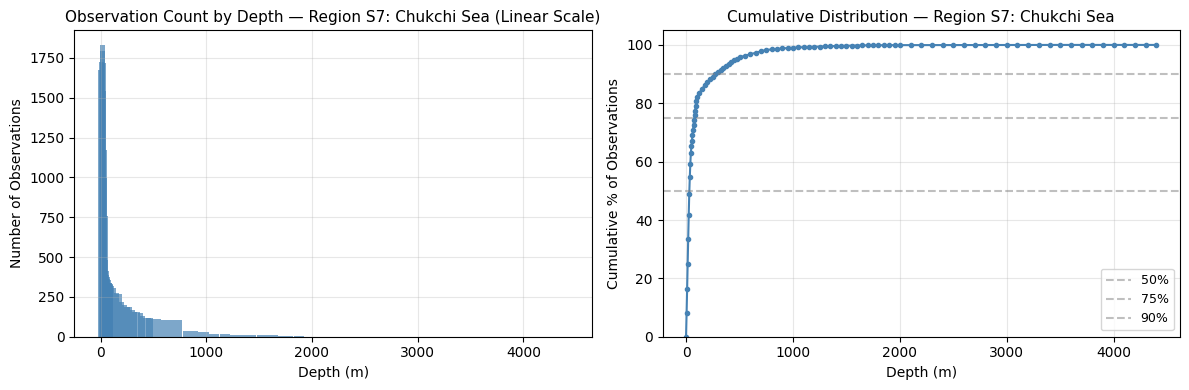

In [24]:
# ============================================================================
# CONFIG: Select region for observation depth analysis
# ============================================================================
REGION_TO_ANALYZE = 'S7'  # Change this to analyze a different region
# ============================================================================

import matplotlib.pyplot as plt

# Print available regions with profile counts
print("=" * 70)
print("AVAILABLE REGIONS WITH PROFILES")
print("=" * 70)
region_counts = {}
for rid in active_regions:
    mask = profile_region == rid
    count = int(mask.sum())
    rname = region_names.get(rid, 'Unknown')
    region_counts[rid] = count
    print(f"  Region {rid:>2s} ({rname:30s}): {count:4d} profiles")

print("\n" + "=" * 70)
print(f"OBSERVATION DISTRIBUTION BY DEPTH — REGION {REGION_TO_ANALYZE}")
print("=" * 70)

# Find the region ID (try both int and string conversion for flexibility)
selected_rid = None
for rid in active_regions:
    if str(rid) == str(REGION_TO_ANALYZE) or rid == REGION_TO_ANALYZE:
        selected_rid = rid
        break

if selected_rid is None:
    print(f"\n⚠️  WARNING: Region {REGION_TO_ANALYZE} not found in active regions!")
    print(f"Available regions: {sorted(active_regions)}")
else:
    # Filter for selected region
    mask_selected = profile_region == selected_rid
    s_obs_selected = S_obs_insitu[mask_selected, :]
    real_mask_selected = real_s_obs_mask[mask_selected, :]
    n_obs_by_depth = np.sum(np.isfinite(s_obs_selected) & real_mask_selected, axis=0)

    rname = region_names.get(selected_rid, 'Unknown')
    print(f"\nRegion ID: {selected_rid}")
    print(f"Region name: {rname}")
    print(f"Total profiles in region: {int(mask_selected.sum())}")
    print(f"Total depths: {len(depths)}")
    print(f"Depth range: {depths[0]:.1f} m to {depths[-1]:.1f} m")
    print(f"Total observations in region: {int(n_obs_by_depth.sum())}")

    # Find depths with observations
    valid_depths_idx = np.where(n_obs_by_depth > 0)[0]
    if len(valid_depths_idx) > 0:
        max_depth_with_obs = depths[valid_depths_idx[-1]]
        min_depth_with_obs = depths[valid_depths_idx[0]]
        print(f"Observation depth range: {min_depth_with_obs:.1f} m to {max_depth_with_obs:.1f} m")
        print(f"Number of depths with observations: {len(valid_depths_idx)} / {len(depths)}")
    else:
        print("⚠️  No observations found at any depth!")

    # Cumulative distribution
    cumsum = np.cumsum(n_obs_by_depth)
    cumsum_norm = cumsum / cumsum[-1] if cumsum[-1] > 0 else cumsum

    # Find depths where 50%, 75%, 90%, 99% of observations occur
    percentiles = [50, 75, 90, 99]
    print("\nCumulative observation percentiles:")
    for p in percentiles:
        threshold = p / 100
        idx = np.argmax(cumsum_norm >= threshold)
        if idx < len(depths):
            print(f"  {p}% of obs. by depth {depths[idx]:.1f} m")

    # Check for shallow water bias
    shallow_threshold = 500  # meters
    n_obs_shallow = np.sum(n_obs_by_depth[depths <= shallow_threshold])
    n_obs_total = n_obs_by_depth.sum()
    pct_shallow = 100 * n_obs_shallow / n_obs_total if n_obs_total > 0 else 0
    print(f"\nObservations in shallow water (≤ {shallow_threshold} m): {int(n_obs_shallow)} ({pct_shallow:.1f}%)")

    # Plot: observations per depth
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Linear scale
    ax1.bar(depths, n_obs_by_depth, width=np.diff(depths).mean(), color='steelblue', alpha=0.7)
    ax1.set_xlabel('Depth (m)', fontsize=10)
    ax1.set_ylabel('Number of Observations', fontsize=10)
    ax1.set_title(f'Observation Count by Depth — Region {selected_rid}: {rname} (Linear Scale)', fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Cumulative distribution
    ax2.plot(depths, cumsum_norm * 100, marker='o', markersize=3, linewidth=1.5, color='steelblue')
    ax2.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50%')
    ax2.axhline(75, color='gray', linestyle='--', alpha=0.5, label='75%')
    ax2.axhline(90, color='gray', linestyle='--', alpha=0.5, label='90%')
    ax2.set_xlabel('Depth (m)', fontsize=10)
    ax2.set_ylabel('Cumulative % of Observations', fontsize=10)
    ax2.set_title(f'Cumulative Distribution — Region {selected_rid}: {rname}', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 105])

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)